In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the data 
# (Make sure sudan.csv is inside your 'data' folder!)
df = pd.read_csv("data/sudan.csv")

# 2. KPI: Add Country column
df["Country"] = "Sudan"

# 3. KPI: Convert YEAR and DOY (Day of Year) into a proper datetime
# NASA uses %j for day of year (1-366)
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. KPI: Extract Month for seasonal analysis
df["Month"] = df["Date"].dt.month

# 5. Preview the transformation
df.head()  

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [6]:
# 1. Define which columns we want to clean
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']

# 2. Replace NASA -999 values
df.replace(-999, np.nan, inplace=True)

# 3. Clean the data using Forward Fill
df[cols] = df[cols].ffill() 

# 4. Export
df.to_csv("data/sudan_clean.csv", index=False)
print("✅ Sudan data is ready!")

✅ Sudan data is ready!


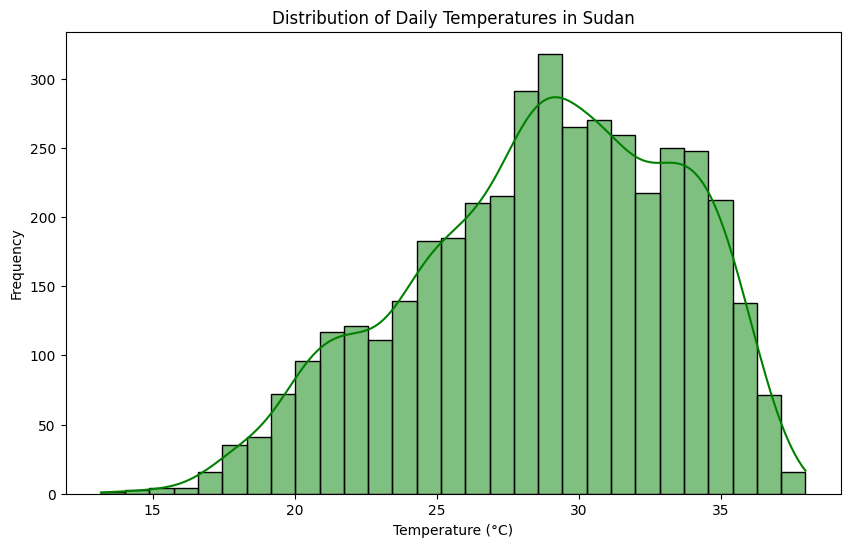

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['T2M'], kde=True, color='green')
plt.title('Distribution of Daily Temperatures in Sudan')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

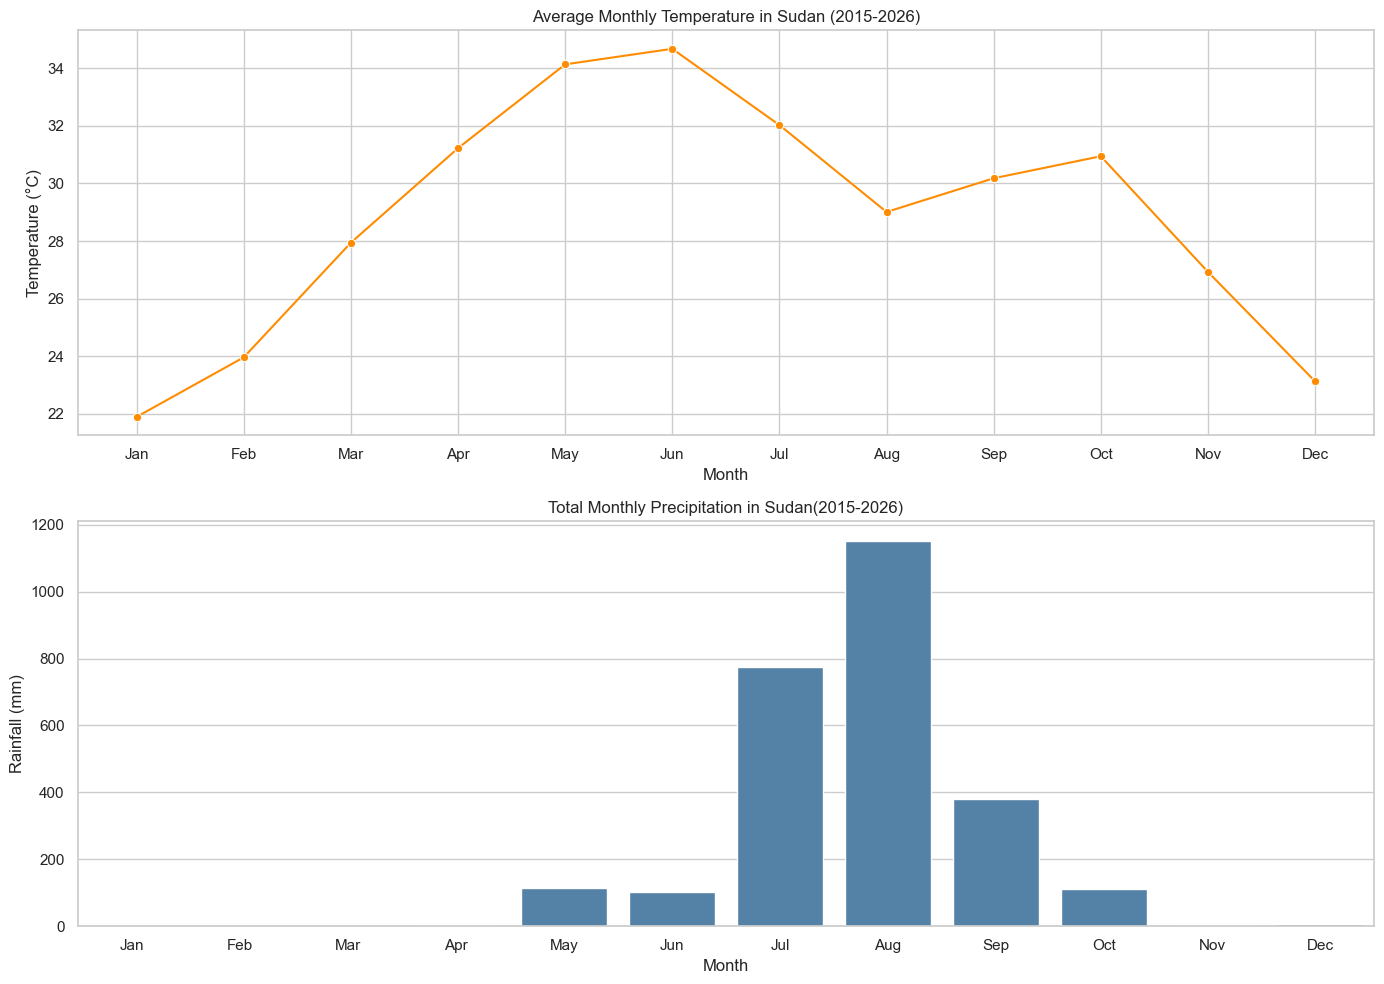

In [8]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Chart 1: Temperature Time Series (Monthly Average)
plt.subplot(2, 1, 1)
monthly_temp = df.groupby('Month')['T2M'].mean()
sns.lineplot(x=monthly_temp.index, y=monthly_temp.values, marker='o', color='darkorange')
plt.title('Average Monthly Temperature in Sudan (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Chart 2: Precipitation (Monthly Total)
plt.subplot(2, 1, 2)
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
sns.barplot(x=monthly_rain.index, y=monthly_rain.values, color='steelblue')
plt.title('Total Monthly Precipitation in Sudan(2015-2026)')
plt.ylabel('Rainfall (mm)')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

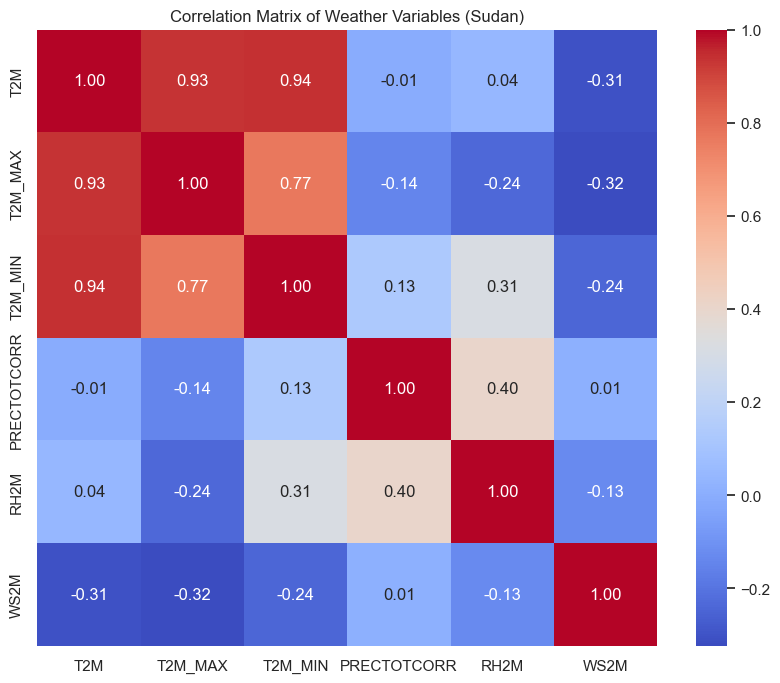

In [10]:
plt.figure(figsize=(10, 8))
# Select only the weather columns for the correlation
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr = df[weather_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Variables (Sudan)')
plt.show()